# 03.1 이미지 전처리

In [ ]:
# !pip install transformers
# !pip install datasets
# !pip install accelerate
# !pip install torch
# !pip install torchvision
# !pip install scikit-learn

# !pip install timm

In [ ]:
# 구글 드라이브 연동
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/7기_컴퓨터비전 응용/교육생제공용/data

/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/7기_컴퓨터비전 응용/교육생제공용/data


In [1]:
import torch
import torchvision.transforms as T
from PIL import Image
import requests
from io import BytesIO

img_path = './tulip_field.png'
# 이미지 열기
img = Image.open(img_path)

# RGB로 변환
img = img.convert("RGB")


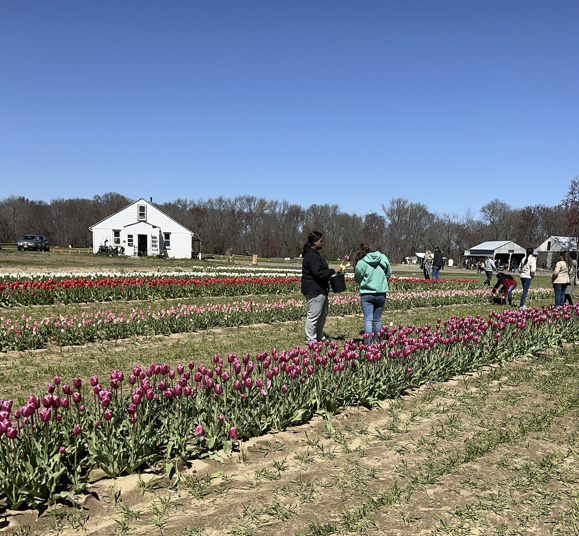

In [2]:
from PIL import Image
from IPython.display import display
# 런타임 17초 소요
# 예: 이미지 크기를 50%로 줄이기
img_resized = img.resize((img.width // 2, img.height // 2))

display(img_resized)

In [7]:
# 데이터 증강 파이프라인 정의
transforms = T.Compose([
    T.RandomRotation(degrees=(-15, 15), fill=0),
    # 이미지를 -15도에서 15도 사이의 각도로 무작위 회전시킵니다.
    # fill=0은 회전으로 인해 발생하는 빈 영역을 검은색(RGB 값이 0)으로 채웁니다.
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    # 이미지의 무작위 부분을 선택하여 224x224 크기로 자르고,
    # 원래 이미지 크기의 80%에서 100% 사이의 임의의 크기로 조정합니다.
    # 이는 모델이 다양한 크기와 비율의 객체에 대해 강건하도록 돕습니다.
    T.RandomHorizontalFlip(p=0.5),
    # 50%의 확률로 이미지를 좌우로 무작위하게 뒤집습니다.
    # 수평 대칭은 이미지의 일반적인 변환 중 하나입니다.
    T.RandomVerticalFlip(p=0.5),
    # 50%의 확률로 이미지를 상하로 무작위하게 뒤집습니다
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # 이미지의 밝기, 대비, 채도, 색조를 무작위로 조절합니다.
    # 각 파라미터는 주어진 범위 내에서 무작위로 변경됨
    # brightness=0.2: 밝기를 원래 값의 +/- 20% 범위 내에서 무작위로 조정
    # contrast=0.2: 대비를 원래 값의 +/- 20% 범위 내에서 무작위로 조정
    # saturation=0.2: 채도를 원래 값의 +/- 20% 범위 내에서 무작위로 조정
    # hue=0.1: 색조를 원래 값의 +/- 10% 범위 내에서 무작위로 조정 (일반적으로 -0.5 ~ 0.5 범위)
    T.ToTensor(),
    # PIL 이미지 또는 NumPy 배열을 PyTorch 텐서로 변환
    # 이 단계에서 이미지 픽셀 값은 0과 1 사이의 부동 소수점 값으로 스케일링됩니다.
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # 텐서 이미지를 정규화함
    # 각 채널별로 평균을 빼고 표준편차로 나누어 데이터의 분포를 조정합니다.
    # 이는 모델 학습을 안정화하고 성능을 향상시키는 데 도움이 됩니다.
    # ImageNet 데이터셋의 평균 및 표준편차 값이 일반적으로 사용됩니다.
])

# 이미지에 데이터 증강파이프라인을 적용
augmented_img = transforms(img)

# 이미지를 시각화하기 위해 해당 이미지를 PIL 이미지로 변환
# 다만, 이 변환 이전에 정규화(normalization) 취소 조치 실행
unnormalized_img = T.Compose([
    T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225]),
    # 정규화된 텐서 값을 원래 스케일로 되돌립니다.
    # >> 정규화에 사용된 평균을 더하고 표준편차를 곱하는 방식으로 수행됩니다.
    T.ToPILImage(),
    # PyTorch 텐서를 PIL 이미지로 변환
    # 텐서의 값은 0과 1 사이여야 하며, 필요에 따라 0-255 범위로 스케일링됩니다.
])(augmented_img)


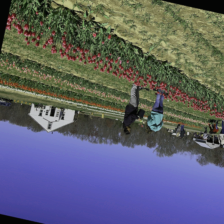

In [8]:
from IPython.display import display

display(unnormalized_img)

---
---

# 03.2 비전 트랜스포머(ViT)

##  Import all Packages

In [9]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [10]:
import timm

all_models = timm.list_models()
vit_models = [model for model in all_models if 'vit' in model]
# 가져온 모든 모델 중에서 이름에 'vit' 문자열이 포함된 모델만 필터링

# 모델 수 카운트 및 출력
print(f"Total number of ViT models: {len(vit_models)}")
print("Available ViT models in timm:")
for model in vit_models:
    print(model)

Total number of ViT models: 370
Available ViT models in timm:
convit_base
convit_small
convit_tiny
crossvit_9_240
crossvit_9_dagger_240
crossvit_15_240
crossvit_15_dagger_240
crossvit_15_dagger_408
crossvit_18_240
crossvit_18_dagger_240
crossvit_18_dagger_408
crossvit_base_240
crossvit_small_240
crossvit_tiny_240
davit_base
davit_base_fl
davit_giant
davit_huge
davit_huge_fl
davit_large
davit_small
davit_tiny
efficientvit_b0
efficientvit_b1
efficientvit_b2
efficientvit_b3
efficientvit_l1
efficientvit_l2
efficientvit_l3
efficientvit_m0
efficientvit_m1
efficientvit_m2
efficientvit_m3
efficientvit_m4
efficientvit_m5
fastvit_ma36
fastvit_mci0
fastvit_mci1
fastvit_mci2
fastvit_mci3
fastvit_mci4
fastvit_s12
fastvit_sa12
fastvit_sa24
fastvit_sa36
fastvit_t8
fastvit_t12
flexivit_base
flexivit_large
flexivit_small
gcvit_base
gcvit_small
gcvit_tiny
gcvit_xtiny
gcvit_xxtiny
levit_128
levit_128s
levit_192
levit_256
levit_256d
levit_384
levit_384_s8
levit_512
levit_512_s8
levit_512d
levit_conv_128
l

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 데이터 준비
우리는 vit_base_patch16_224 모델을 사용할 예정입니다.
이는 모든 이미지를 (224, 224) 크기로 리사이징해야 함을 의미합니다.

학습 과정에서는 다음과 같은 데이터 증강(Data Augmentation) 기법을 사용합니다:
RandomHorizontalFlip (수평 뒤집기)
이 단계는 선택 사항입니다.
입력 이미지를 무작위로 수평으로 뒤집습니다.
이는 학습 데이터셋의 크기와 다양성을 인위적으로 증가시키는 데 도움이 됩니다.

또한 이미지 정규화(transforms.Normalize)도 수행합니다:
이미지의 스케일(값의 범위)을 줄이는 작업입니다.

정규화는 다음과 같은 이점을 줍니다:

* 더 빠른 수렴

* 더 나은 일반화 성능

* 수치 안정성 향상




In [11]:
import kagglehub
import shutil
import os

# 1. 데이터셋 다운로드
path = kagglehub.dataset_download("jr2ngb/cataractdataset")

# 2. 저장할 대상 경로 설정
target_dir = "./"

# 3. 디렉토리 없으면 생성
os.makedirs(target_dir, exist_ok=True)

# 4. 다운로드된 데이터셋을 대상 경로로 복사
shutil.copytree(path, target_dir, dirs_exist_ok=True)
# shutil.copytree() 함수를 사용하여 원본 디렉토리(path)의 모든 내용 (파일 및 하위 디렉토리)을
# 대상 디렉토리(target_dir)로 재귀적으로 복사합니다.
# dirs_exist_ok=True 옵션은 대상 디렉토리가 이미 존재할 경우 오류를 발생시키지 않고,
# 기존 디렉토리 내부에 새로운 내용을 병합하도록 합니다.
print("Dataset copied to:", target_dir)

100%|██████████| 3.34G/3.34G [01:51<00:00, 32.1MB/s]

Extracting files...


Dataset copied to: ./


In [12]:
# 필요한 라이브러리 불러오기
# 데이터 경로 설정 (자신의 구글 드라이브 경로에 맞게 수정 필요)
# 실습 데이터셋 용량이 크므로, 축소된 버전 사용
# 폴더당 이미지 10개만 포함되어 있어 빠른 실습 가능

DATA_DIR = "./dataset"

# 클래스 이름 지정 (숫자 접두어 포함)
CLASSES = ["1_normal", "2_cataract", "2_glaucoma", "3_retina_disease"]

# 전체 데이터 경로 및 레이블 리스트 구성
data = []
for class_idx, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        data.append([img_path, class_idx])  # 이미지 경로와 해당 클래스 인덱스를 저장

# 데이터프레임으로 변환
df = pd.DataFrame(data, columns=["image_path", "label"])
print(df)

# 학습/테스트 데이터 분할 (stratify로 클래스 비율 유지)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

# 학습용 이미지 전처리 정의
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                   # 입력 사이즈 224x224로 리사이징 (ViT 요구)
    transforms.RandomHorizontalFlip(),               # 수평 뒤집기 (데이터 증강)
    transforms.ToTensor(),                           # 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 정규화 (ImageNet 기준)
                         std=[0.229, 0.224, 0.225]),
])

# 테스트용 이미지 전처리 정의 (증강 없이 정규화만)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 커스텀 데이터셋 클래스 정의
class CataractDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)  # 전체 데이터 수 반환

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert("RGB")  # 이미지 로드 및 RGB 변환

        if self.transform:
            img = self.transform(img)  # 전처리 적용

        return img, label  # 이미지와 레이블 반환

# 학습 및 테스트용 데이터셋 생성
train_dataset = CataractDataset(train_df["image_path"].values,
                                train_df["label"].values,
                                transform=train_transforms)
test_dataset = CataractDataset(test_df["image_path"].values,
                               test_df["label"].values,
                               transform=test_transforms)
# train_df["image_path"].values: "image_path"라는 컬럼의 모든 값들을 NumPy 배열 형태로 추출(학습 이미지 파일 경로)
# train_df["label"].values: 서 "label"이라는 컬럼의 모든 값들을 NumPy 배열 형태로 추출(학습이미지 라벨(정답) 정보)


# 데이터로더 구성
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)   # 학습용 로더 (shuffle 활성화)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)    # 테스트용 로더 (shuffle 없음)


                                    image_path  label
0                ./dataset/1_normal/NL_122.png      0
1                ./dataset/1_normal/NL_281.png      0
2                ./dataset/1_normal/NL_180.png      0
3                ./dataset/1_normal/NL_278.png      0
4                ./dataset/1_normal/NL_149.png      0
..                                         ...    ...
596  ./dataset/3_retina_disease/Retina_077.png      3
597  ./dataset/3_retina_disease/Retina_041.png      3
598  ./dataset/3_retina_disease/Retina_071.png      3
599  ./dataset/3_retina_disease/Retina_058.png      3
600  ./dataset/3_retina_disease/Retina_100.png      3

[601 rows x 2 columns]


## 데이터로더 검토
우리는 train_dataloader에서 이미지를 시각화하고 있습니다.
여기서 매우 중요한 한 가지 단계가 있습니다:

이미지 형식 차이:
**matplotlib**은 이미지 형태를 [H, W, C] (높이, 너비, 채널)로 요구합니다.

하지만 **PyTorch Dataloader**는 이미지를 [C, H, W] (채널, 높이, 너비) 형식으로 제공합니다.

따라서, 시각화 전에 이미지를 transpose (차원 변경) 해야 합니다:

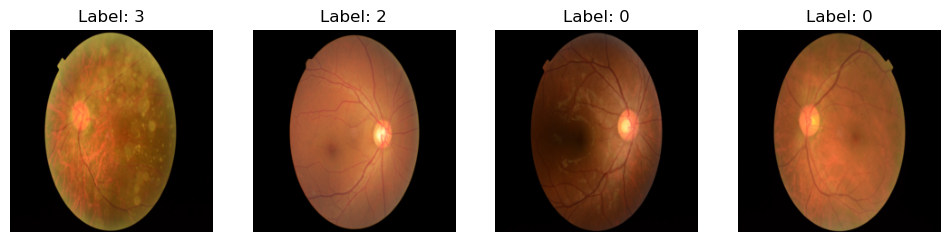

In [13]:
# 필요한 라이브러리 임포트
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 학습 데이터로더(train_loader)에서 하나의 배치(batch)를 추출합니다.
# iter() 함수를 사용하여 데이터로더를 iterable 객체로 만들고,
# next() 함수를 호출하여 다음 배치를 가져옵니다.
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 이미지 텐서를 matplotlib에 맞게 변환하는 함수 (역정규화 포함)
def imshow(img_tensor):
    img = img_tensor.numpy()                         # 텐서를 넘파이 배열로 변환
    img = np.transpose(img, (1, 2, 0))               # [C, H, W] → [H, W, C]로 변환(차원 순서 변경)
    mean = np.array([0.485, 0.456, 0.406])           # 정규화 시 사용된 평균
    std = np.array([0.229, 0.224, 0.225])            # 정규화 시 사용된 표준편차
    img = std * img + mean                           # 정규화 복원 (역정규화)
    img = np.clip(img, 0, 1)                         # 픽셀 값을 0~1 사이로 클리핑
    return img                                       # 이미지 반환

# 이미지와 레이블 시각화
fig, axes = plt.subplots(1, len(images), figsize=(12, 12))  # 배치 크기만큼 subplot 생성

for idx, (image, label) in enumerate(zip(images, labels)):
    axes[idx].imshow(imshow(image))                # 이미지 디스플레이
    axes[idx].set_title(f"Label: {label.item()}")  # 레이블 표시
    axes[idx].axis("off")                          # 축 제거

plt.show()  # 전체 이미지 출력


## 모델 선언
우리는 timm 라이브러리에서 사전 학습된(pre-trained) Vision Transformer 모델을 사용할 것입니다.

주요 설정(항목	설명)
1. in_chans=3	이미지가 **컬러(RGB)**인 경우, 입력 채널 수는 3 \
2. in_chans=1	이미지가 **흑백(Grayscale)**인 경우, 입력 채널 수는 1
3. num_classes=4	분류할 클래스의 수입니다. 이 예제에서는 클래스가 4개
4. pretrained=True	사전 학습된 가중치 사용을 명시합니다.
5. pretrained=False	만약 처음부터 학습하고 싶다면, False로 설정하면 됩니다.

In [14]:
# timm 라이브러리에서 Vision Transformer 모델 생성
import timm

# 사전 학습된 ViT 모델 로드
# - 모델 이름: vit_base_patch16_224
# - 입력 채널 수: 3 (RGB 이미지)
# - 클래스 수: 4 (현재 분류 문제에서 클래스가 4개)
# - pretrained=True: ImageNet으로 사전 학습된 가중치 사용

model = timm.create_model(
    "vit_base_patch16_224",  # 모델 아키텍처
    in_chans=3,              # 입력 채널 수 (컬러 이미지: 3)
    num_classes=4,           # 출력 클래스 수
    pretrained=True          # 사전 학습 가중치 사용
)



## 학습 및 테스트 루프 선언

아래 코드에서는 `output`과 `target`을 `'cpu'`로 변환하고 있습니다.  
이는 제 **M1 칩에서 문제가 발생했기 때문**이며,  
**여러분의 환경에서는 문제가 발생하지 않을 수도 있습니다.**  

따라서, 이 부분은 **완전히 선택적인(optional) 단계**입니다.

In [15]:
# 학습 함수 정의
def train(model, device, train_loader, optimizer, criterion, epoch, accelerator):
    model.train()                        # 모델을 학습 모드로 설정
    running_loss = 0.0                   # epoch 전체 손실 초기화

    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data, target = data.to(device), target.to(device)  # 데이터와 라벨을 디바이스로 이동
        optimizer.zero_grad()            # 누적된 기울기 초기화
        output = model(data)             # 모델에 입력
        loss = criterion(output, target) # 손실 계산
        accelerator.backward(loss)       # 손실에 대해 역전파
        optimizer.step()                 # 가중치 업데이트
        running_loss += loss.item()      # 손실 누적

    avg_loss = running_loss / len(train_loader)     # 평균 손실 계산
    print(f"Epoch: {epoch}, Loss: {avg_loss:.4f}")  # Epoch별 손실 출력

# 테스트 함수 정의 (정확도, 손실, 민감도, 특이도 계산 포함)
from sklearn.metrics import confusion_matrix, recall_score, precision_score

def test(model, device, test_loader, criterion, accelerator):
    model.eval()                   # 평가 모드로 설정
    test_loss = 0                  # 테스트 손실 초기화
    correct = 0                    # 정확한 예측 수 초기화
    all_preds = []                 # 전체 예측값 저장 리스트
    all_targets = []               # 전체 정답값 저장 리스트

    with torch.no_grad():         # 평가 시에는 gradient 계산하지 않음
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()  # 손실 누적
            # 현재 배치의 손실을 계산하고, 전체 테스트 손실에 누적합니다.
            # >> .item()을 사용하여 텐서에서 스칼라 값을 추출

            output_cpu = output.to('cpu')                  # CPU로 이동
            target_cpu = target.to('cpu')
            pred = output_cpu.argmax(dim=1, keepdim=True)  # 가장 높은 확률의 클래스 선택
            # 모델의 출력(각 클래스에 대한 확률 또는 로짓 값)에서 가장 높은 값을 갖는 인덱스를 예측된 클래스로 선택합니다.
            # argmax(dim=1)은 배치 내 각 샘플에 대해 가장 높은 값의 인덱스를 반환
            # keepdim=True는 결과 텐서의 차원을 유지하여 타겟 텐서와의 비교를 용이하게 함.

            correct += pred.eq(target_cpu.view_as(pred)).sum().item()
            # 예측(pred)이 실제 타겟(target_cpu)과 일치하는 샘플의 수를 계산하여 전체 정확하게 예측한 수(correct)에 더합니다.
            # target_cpu.view_as(pred)는 타겟 텐서의 형태를 예측 텐서와 동일하게 만들어 비교할 수 있도록 함
            # .sum().item()은 일치하는 bool 텐서의 True 값의 합을 스칼라로 반환

            # 현재 배치의 예측 결과, 실제 타겟 레이블을 1차원 리스트로 변환하여 전체 예측 결과 리스트에 추가
            all_preds.extend(pred.flatten().tolist())      # 예측 결과 저장
            all_targets.extend(target.flatten().tolist())  # 실제 레이블 저장

    test_loss /= len(test_loader)                          # 평균 손실 계산
    accuracy = 100. * correct / len(test_loader.dataset)   # 정확도 계산
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    # 혼동 행렬 계산
    cm = confusion_matrix(all_targets, all_preds)

    # 클래스별 민감도(리콜): 실제 클래스 중에서 맞춘 비율
    sensitivity = recall_score(all_targets, all_preds, average=None)
    # average=None으로 설정하면 각 클래스별 리콜 값을 배열로 반환합니다.

    # 클래스별 특이도: (TN) / (TN + FP) 계산
    # 특이도는 실제 음성(True Negative)인 샘플 중에서 모델이 정확하게 음성으로 예측한 비율을 나타냅니다.
    # 공식: TN / (TN + FP)
    specificity = (cm.sum(axis=0) - cm.diagonal()) / cm.sum(axis=0)
    # cm.sum(axis=0)는 각 예측 클래스별로 총 샘플 수를 나타냅니다 (True Positives + False Positives).
    # cm.diagonal()는 각 실제 클래스와 예측 클래스가 일치하는 (True Positives) 값을 담고 있는 배열입니다.
    # 따라서 (cm.sum(axis=0) - cm.diagonal())는 각 클래스별 False Positives (FP) 값을 나타냅니다.

    # 각 클래스에 대해 민감도 및 특이도 출력
    for i, (sens, spec) in enumerate(zip(sensitivity, specificity)):
        print(f"Class {i}: Sensitivity (Recall): {sens:.4f}, Specificity: {spec:.4f}")


In [16]:
# accelerate 라이브러리로 분산 학습 환경 초기화
from accelerate import Accelerator
from torch.optim import Adam

# Accelerator 객체 생성 및 디바이스 설정
accelerator = Accelerator()
device = accelerator.device  # GPU 또는 CPU 자동 선택

# 학습률 설정
learning_rate = 1e-4

# 최적화 알고리즘 정의 (Adam 사용)
optimizer = Adam(model.parameters(), lr=learning_rate)

# 손실 함수 정의 (다중 클래스 분류이므로 CrossEntropyLoss 사용)
criterion = nn.CrossEntropyLoss()

# 데이터로더를 accelerator에 맞게 준비 (멀티-GPU, mixed-precision 등에 최적화됨)
train_loader, test_loader = accelerator.prepare(train_loader, test_loader)

# 모델, 옵티마이저, 손실 함수도 accelerator에 맞게 준비
model, optimizer, criterion = accelerator.prepare(model, optimizer, criterion)


In [17]:
# 학습 루프 설정
# 참고: 실행 시간을 줄이기 위해 epoch 수를 10으로 설정
# 원래 설정은 num_epochs = 50

# num_epochs = 50
num_epochs = 10

# 지정된 epoch 수만큼 반복
for epoch in range(1, num_epochs + 1):
    train(model, device, train_loader, optimizer, criterion, epoch, accelerator)  # 한 epoch 학습
    test(model, device, test_loader, criterion, accelerator)                      # 해당 epoch 후 성능 평가


100%|██████████| 120/120 [00:32<00:00,  3.64it/s]


Epoch: 1, Loss: 1.3685


/tmp/ipykernel_224967/2955438658.py:66: RuntimeWarning: invalid value encountered in divide
  specificity = (cm.sum(axis=0) - cm.diagonal()) / cm.sum(axis=0)


Test Loss: 1.3175, Accuracy: 52.07%
Class 0: Sensitivity (Recall): 1.0000, Specificity: 0.4874
Class 1: Sensitivity (Recall): 0.1000, Specificity: 0.0000
Class 2: Sensitivity (Recall): 0.0000, Specificity: nan
Class 3: Sensitivity (Recall): 0.0000, Specificity: nan


100%|██████████| 120/120 [00:32<00:00,  3.67it/s]


...

/tmp/ipykernel_224967/2955438658.py:66: RuntimeWarning: invalid value encountered in divide
  specificity = (cm.sum(axis=0) - cm.diagonal()) / cm.sum(axis=0)


Test Loss: 1.1991, Accuracy: 52.89%
Class 0: Sensitivity (Recall): 1.0000, Specificity: 0.4786
Class 1: Sensitivity (Recall): 0.1500, Specificity: 0.0000
Class 2: Sensitivity (Recall): 0.0000, Specificity: 1.0000
Class 3: Sensitivity (Recall): 0.0000, Specificity: nan


100%|██████████| 120/120 [00:32<00:00,  3.69it/s]


Epoch: 10, Loss: 0.9848
Test Loss: 1.0057, Accuracy: 60.33%
Class 0: Sensitivity (Recall): 0.8361, Specificity: 0.3704
Class 1: Sensitivity (Recall): 0.3500, Specificity: 0.0000
Class 2: Sensitivity (Recall): 0.7500, Specificity: 0.5455
Class 3: Sensitivity (Recall): 0.0000, Specificity: nan


/tmp/ipykernel_224967/2955438658.py:66: RuntimeWarning: invalid value encountered in divide
  specificity = (cm.sum(axis=0) - cm.diagonal()) / cm.sum(axis=0)


## 결과 분석 (Analysis):
### 1. 손실(loss)이 감소하고 있음 → 모델이 학습되고 있다는 의미
### 2. 더 많은 epoch이 필요함 → 현재 epoch 수로는 충분한 성능 도달 어려움

---

# 03.3 Detection 트랜스포머(DETR)

## 라이브러리 불러오기

In [18]:
# 기본 라이브러리 및 객체 탐지 모델 관련 패키지 임포트

import torch                              # PyTorch
import torchvision.transforms as T        # 이미지 전처리(transform) 도구
from PIL import Image                     # 이미지 처리용 PIL
import requests                           # 웹 이미지 로딩용
from io import BytesIO                    # 바이너리 데이터 스트림 처리
import matplotlib.pyplot as plt           # 이미지 시각화

# Hugging Face Transformers 라이브러리에서 DETR 모델 및 전처리 도구 임포트
from transformers import DetrForObjectDetection, DetrImageProcessor


## 모델 로드

In [19]:
# Hugging Face Transformers 라이브러리에서 DETR 모델 구성 요소 불러오기
from transformers import DetrImageProcessor, DetrForObjectDetection, DetrConfig

# DETR 모델 구성(config) 명시적으로 정의
# config를 명시해주는 방식은 추후 커스터마이징 시 유용함
config = DetrConfig.from_pretrained("facebook/detr-resnet-50")

# 이미지 전처리용 프로세서 로드 (이미지 → 모델 입력 변환)
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# DETR 객체 탐지 모델 로드 (사전 학습된 가중치 사용, config도 명시)
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", config=config)

# 모델을 평가 모드로 전환 (추론 시 필수)
model.eval()



Loading weights: 100%|██████████| 530/530 [00:00<00:00, 2529.05it/s, Materializing param=model.query_position_embeddings.weight]                 
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvEncoder(
      (model): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): DetrFrozenBatchNorm2d()
        (act1): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): DetrFrozenBatchNorm2d()
            (drop_block): Identity()
            (act2): ReLU(inplace=True)
            (aa): Identity()
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): DetrFrozenBatchNorm2d()
            (act3): ReLU(inplace

In [20]:
img_path = './tulip_field.png'

# 이미지 열기
img = Image.open(img_path)

# RGB로 변환
img = img.convert("RGB")

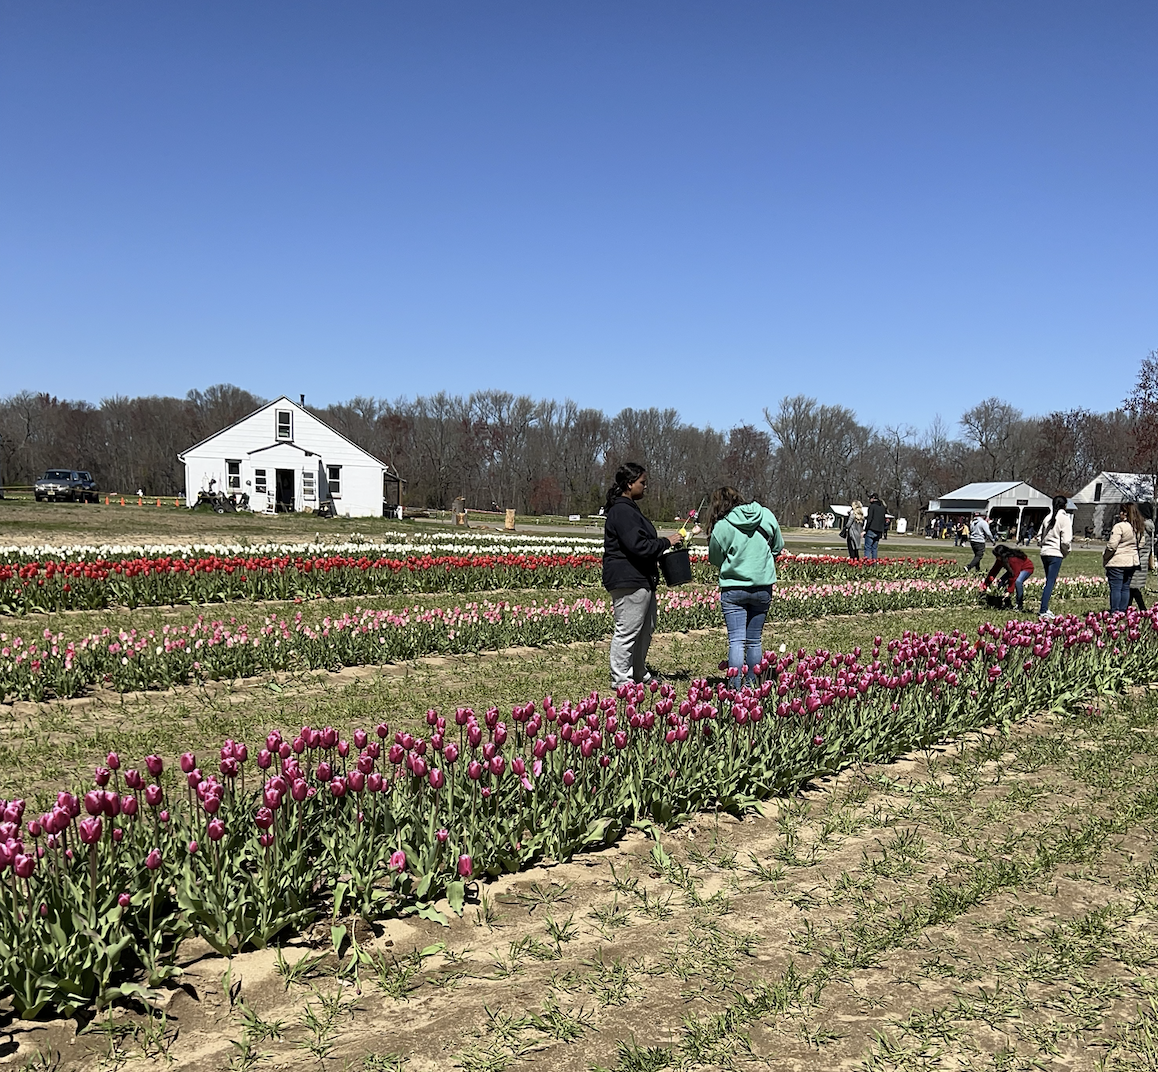

In [21]:
img

In [22]:
# torchvision.transforms를 활용한 이미지 전처리 파이프라인 정의
transform = T.Compose([
    T.Resize(800),                          # 가장 짧은 변이 800픽셀이 되도록 리사이즈
    T.ToTensor(),                           # PIL 이미지를 PyTorch 텐서로 변환 (범위: [0, 1])
    T.Normalize([0.485, 0.456, 0.406],      # ImageNet 기준 평균값으로 정규화
                [0.229, 0.224, 0.225]),     # ImageNet 기준 표준편차로 정규화
])

# 이미지에 전처리를 적용하고 배치 차원을 추가 (unsqueeze(0): [C, H, W] → [1, C, H, W])
img_tensor = transform(img).unsqueeze(0)

## Perform the Prediction

In [23]:
# 추론 시에는 gradient 계산을 하지 않도록 설정 (메모리 절약 및 속도 향상)
with torch.no_grad():
    outputs = model(img_tensor)  # 모델에 전처리된 이미지 입력하여 결과 얻음

# 이미지 원본 사이즈를 모델 출력에 맞게 전달 (img.size는 (W, H)이므로 뒤집어서 (H, W)로 전달)
target_sizes = torch.tensor([img.size[::-1]])

# DETR 모델의 raw output을 실제 객체 탐지 결과로 후처리
# - threshold=0.9: confidence score가 0.9 이상인 경우만 필터링
# - 결과는 리스트로 반환되며, [0]을 통해 첫 번째 이미지 결과를 선택
results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.9)[0]
# processor: 이는 일반적으로 Hugging Face Transformers 라이브러리에서 제공하는 객체 검출 모델의 전처리 및 후처리 기능을 통합한 유틸리티 클래스의 인스턴스
# threshold=0.9: 이는 검출된 객체의 신뢰도(confidence) 임계값

## Plot the Prediction

person
person
handbag
person
car
person
person
person


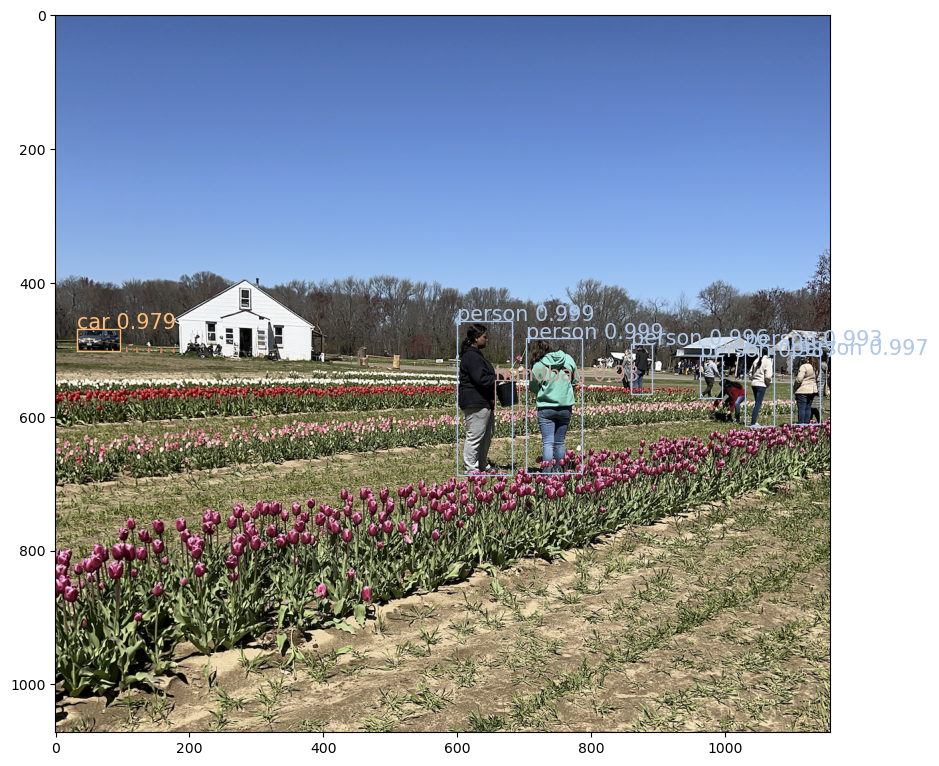

In [25]:
# 시각화용 subplot 생성 (10x10 사이즈)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(img)  # 원본 이미지 표시

# 객체마다 고유 색상 배정 위해 tab20 컬러맵 사용 (최대 20가지 색상)
colors = plt.get_cmap("tab20").colors

# DETR 후처리 결과(results)에서:
# - scores: 객체 탐지 confidence
# - labels: 예측 클래스 인덱스
# - boxes: 경계 상자 좌표 [x1, y1, x2, y2]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    x, y, w, h = box  # 좌표 추출
    w = w - x         # 너비 계산
    h = h - y         # 높이 계산
    # x, y, w, h = box  검출된 객체의 바운딩 박스 좌표를 추출합니다.
    # >> [xmin, ymin, xmax, ymax] 형태
    # 추출된 xmax에서 xmin을 빼서 바운딩 박스의 너비(width)를 계산
    # # 추출된 ymax에서 ymin을 빼서 바운딩 박스의 높이(height)계산

    # 경계 상자 그리기 (색상은 label에 따라 고유하게 지정)
    rect = plt.Rectangle(
        (x, y), w, h,
        # 좌측 하단 좌표 (x, y), 너비 w, 높이 h를 사용하여 사각형을 정의
        linewidth=1,
        # 경계선의 두께를 1로 설정
        edgecolor=colors[label % 20],
        # 경계선의 색상을 지정
        # >> label 값을 20으로 나눈 나머지 값을 인덱스로 사용하여 각 클래스에 고유한 색상을 할당.
        facecolor="none"
        # 사각형 내부를 투명하게 설정
    )
    ax.add_patch(rect)  # 사각형 추가
    # 현재 axes 객체(ax)에 생성한 사각형(경계 상자)을 추가

    # 라벨 텍스트 및 confidence 점수 출력
    ax.text(
        x, y,
         # 텍스트를 표시할 좌측 하단 좌표를 바운딩 박스의 좌측 하단과 동일하게 설정
        f"{model.config.id2label[label.item()]} {round(score.item(), 3)}",
        # label.item()은 텐서 형태의 레이블 ID를 Python 스칼라 값으로 변환
        # round(score.item(), 3)은 텐서 형태의 신뢰도 점수를 스칼라 값으로 변환하고 소수점 셋째 자리까지 반올림
        fontsize=15,
        color=colors[label % 20]
        # 텍스트의 색상을 해당 객체의 경계 상자와 동일한 색상으로 지정
    )
    print(model.config.id2label[label.item()])

plt.show()  # 최종 결과 시각화
